<a href="https://colab.research.google.com/github/DJM2142003/Assignment-2/blob/main/INFO4670_Assignment_SMS_Spam_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [5]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
>Typically, a false positive has a higher cost than a false negative. The reason for this is that when the system identifies an actual message as a spam message (false positive), it will block access to an actual message that you probably needed at some time, like a bank alert, school announcement, or even a job response. On the other hand, if the system fails to identify spam mail as such (false negative), users may be exposed to potential scams or phishing attempts. In reality, however, if the system consistently blocks legitimate communications from reaching their destination, it could severely erode the trust of users and cause them to file formal complaints with the service provider.


**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> The most important evaluation criterion in this case is Precision. If your priority is preventing incorrect identification of real messages, high Precision means that when the model identifies a message as spam, it is usually correct; thus, fewer "real" messages are incorrectly blocked by the model's error.

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> Based on the assumption that there is approximately 13 percent spam and therefore approximately 87 percent ham, using a dummy model that always predicts ham would result in an approximate accuracy of 87%. This represents a misleading measure of performance since the dummy model correctly identified no spam messages, so its apparent strength based on accuracy is illusory.


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [6]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


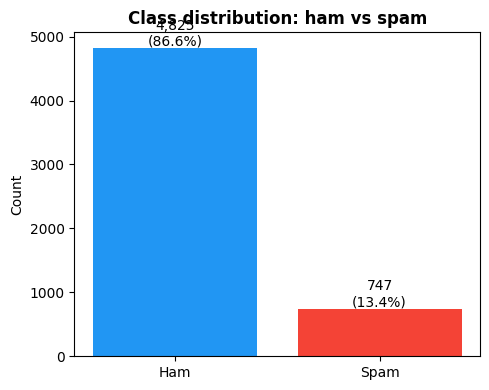

In [7]:
# Write your code here
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# Prove the accuracy trap with a dummy model
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [8]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


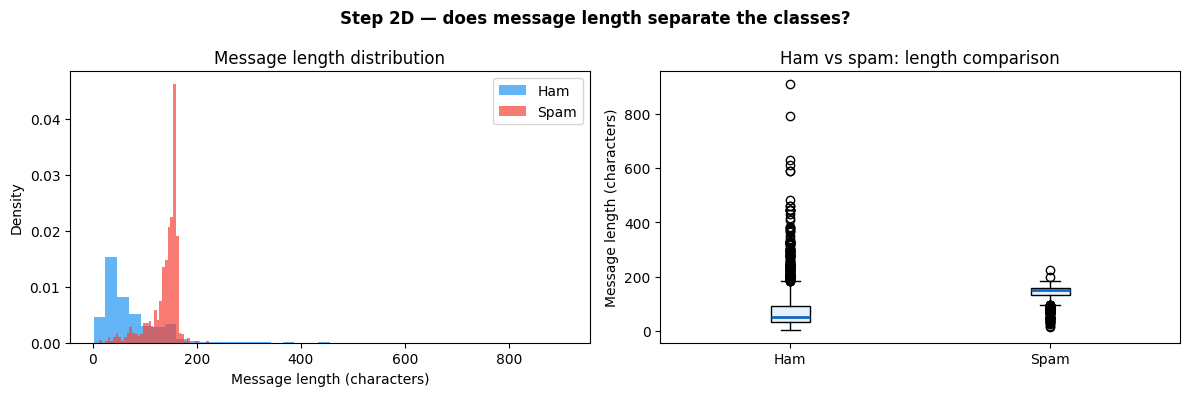

In [9]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [10]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [11]:
# Write your code here

def build_features_v2(df):
    d = build_features(df)   # keeps all 4 starter features
    msg = d['message'].str.lower()

    # Feature 5: command/action words often seen in spam
    d['has_text_cmd'] = msg.str.contains(
        r'\b(txt|text|reply|stop|send)\b',
        regex=True
    ).astype(int)

    # Feature 6: URL detection
    d['has_url'] = msg.str.contains(
        r'(http[s]?://|www\.)',
        regex=True
    ).astype(int)

    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam'] == 1][feat].mean()
    ha = df[df['spam'] == 0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
has_text_cmd           48.9%    5.6%  +43.3%
has_url                14.2%    0.0%  +14.1%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


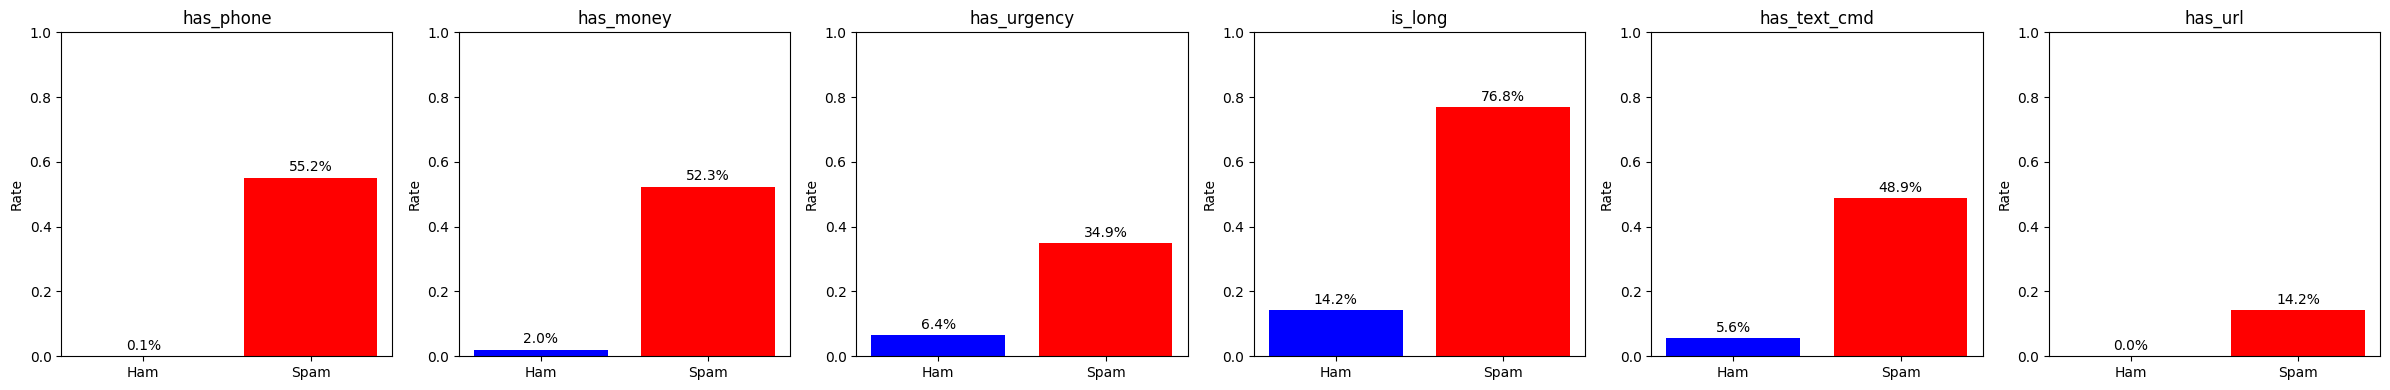

In [12]:
n = len(feature_cols)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

if n == 1:
    axes = [axes]

for ax, feat in zip(axes, feature_cols):
    spam_rate = df[df['spam']==1][feat].mean()
    ham_rate = df[df['spam']==0][feat].mean()

    ax.bar(['Ham', 'Spam'], [ham_rate, spam_rate], color=['blue', 'red'])
    ax.set_ylim(0, 1)
    ax.set_title(feat)
    ax.set_ylabel('Rate')
    for i, v in enumerate([ham_rate, spam_rate]):
        ax.text(i, v + 0.02, f'{v:.1%}', ha='center')

plt.tight_layout()
plt.show()

### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — name and explanation:*
> Feature 1: has_text_cmd
has_text_cmd examines command-type words used in spam communications such as "txt," "text," "reply", "stop" & "send." The reason is that many spammers will attempt to prompt you to immediately respond to them using either of those commands.

*Feature 2 — name and explanation:*
> Feature 2: has_url
Has_url examines whether a message contains a website link (i.e. Http or www). Spam messages frequently contain links to phony promotional sites, phishing pages or scam sites.

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> The feature that produces the largest difference between spam and ham is likely to be the strongest classifier since it occurs significantly more in spam than in ham. The reason this matters is that a Decision tree maximizes the amount of Information Gain at each split, thus the root node should utilize the feature that most effectively classifies the data. If there is one feature that can classify spam from ham better than all other features then it is reducing the impurity of the data the most and therefore would be a good choice for the root.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> It is possible to create a spam message that circumvents some of these features by using professional-sounding language while avoiding obvious spam words, no phone numbers, no links and no reply commands. An example of such an email might read like: "account activity requires verification. Review your recent login history." Since this type of message does not include any of the features examined above (i.e., has_phone, has_money, has_urgency, has_text_cmd and has_url), this could potentially become a false-negative.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [13]:
X = df[feature_cols].values
y = df['spam'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print('Split sizes:')
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

print('\nSpam rates:')
print(f'Train spam rate: {y_train.mean():.1%}')
print(f'Test spam rate : {y_test.mean():.1%}')

Split sizes:
X_train: (4179, 6)
X_test : (1393, 6)
y_train: (4179,)
y_test : (1393,)

Spam rates:
Train spam rate: 13.4%
Test spam rate : 13.4%


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> Stratifying our data using stratify=y helps maintain a relatively consistent spam-to-ham message ratio in both the testing and training datasets. When working with an unbalanced dataset, not stratifying your data can cause the testing dataset to have too little spam, creating an unstable/ineffective model evaluation.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> When we don't know what the size of the dataset is going to be, or if we just need a more stable way to measure how well a model performs, we should perform cross-validation. Cross-validation decreases the chances of getting a train/test split where either the model performs extremely poorly or extremely well due to chance.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Number of leaves: 14


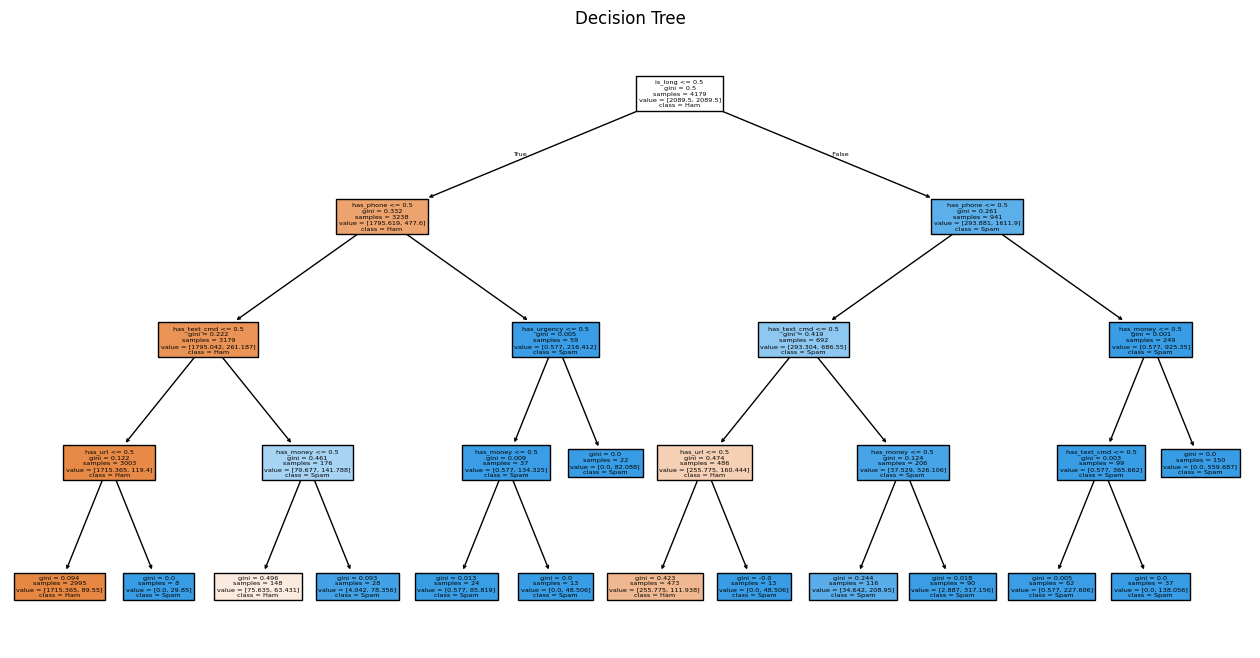

|--- is_long <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- has_text_cmd <= 0.50
|   |   |   |--- has_url <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_url >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_text_cmd >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |--- has_phone >  0.50
|   |   |--- has_urgency <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_urgency >  0.50
|   |   |   |--- class: 1
|--- is_long >  0.50
|   |--- has_phone <= 0.50
|   |   |--- has_text_cmd <= 0.50
|   |   |   |--- has_url <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_url >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_text_cmd >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |--

In [14]:
dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight='balanced'
)
dt.fit(X_train, y_train)

print('Number of leaves:', dt.get_n_leaves())

plt.figure(figsize=(16, 8))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=['Ham', 'Spam'],
    filled=True
)
plt.title('Decision Tree')
plt.show()

print(export_text(dt, feature_names=feature_cols))

### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


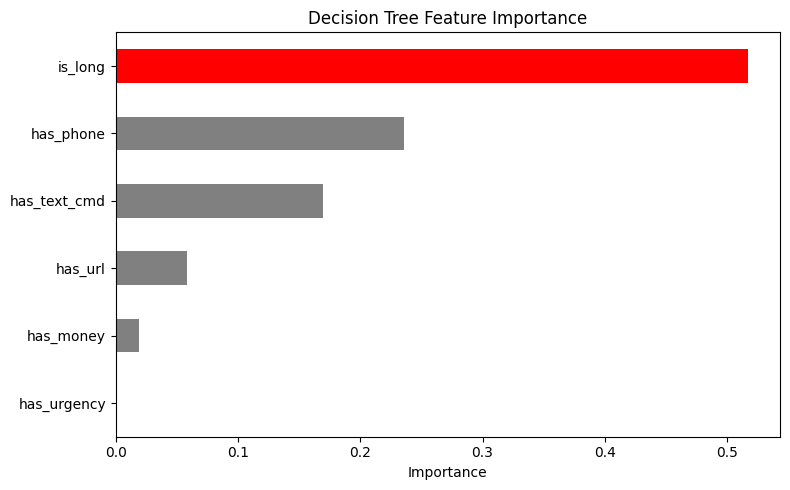

In [15]:
importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values()

colors = ['gray'] * len(importances)
colors[-1] = 'red'

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color=colors)
plt.xlabel('Importance')
plt.title('Decision Tree Feature Importance')
plt.tight_layout()
plt.show()

### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


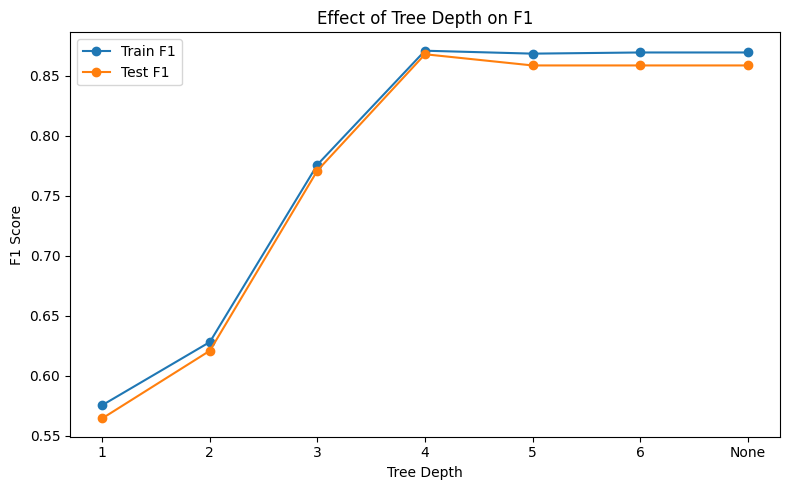

In [16]:
depths = [1, 2, 3, 4, 5, 6, None]
train_f1 = []
test_f1 = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42,
        class_weight='balanced'
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_f1.append(f1_score(y_train, y_train_pred))
    test_f1.append(f1_score(y_test, y_test_pred))

plt.figure(figsize=(8, 5))
plt.plot([str(d) for d in depths], train_f1, marker='o', label='Train F1')
plt.plot([str(d) for d in depths], test_f1, marker='o', label='Test F1')
plt.xlabel('Tree Depth')
plt.ylabel('F1 Score')
plt.title('Effect of Tree Depth on F1')
plt.legend()
plt.tight_layout()
plt.show()

### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [18]:
nb = BernoulliNB()
nb.fit(X_train, y_train)

BernoulliNB()

---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


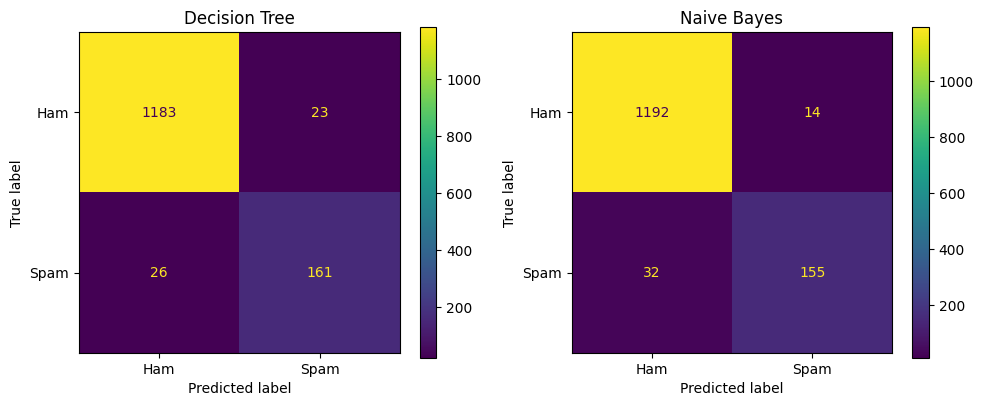

Decision Tree:
TP = 161 FP = 23 FN = 26 TN = 1183

Naive Bayes:
TP = 155 FP = 14 FN = 32 TN = 1192


In [19]:
y_pred_dt = dt.predict(X_test)
y_pred_nb = nb.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['Ham', 'Spam'],
    ax=axes[0]
)
axes[0].set_title('Decision Tree')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb,
    display_labels=['Ham', 'Spam'],
    ax=axes[1]
)
axes[1].set_title('Naive Bayes')

plt.tight_layout()
plt.show()

cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_nb = confusion_matrix(y_test, y_pred_nb)

tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()
tn_nb, fp_nb, fn_nb, tp_nb = cm_nb.ravel()

print('Decision Tree:')
print('TP =', tp_dt, 'FP =', fp_dt, 'FN =', fn_dt, 'TN =', tn_dt)

print('\nNaive Bayes:')
print('TP =', tp_nb, 'FP =', fp_nb, 'FN =', fn_nb, 'TN =', tn_nb)

### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


           Model  Accuracy  Precision    Recall  F1-Score
0  Decision Tree  0.964824    0.87500  0.860963  0.867925
1    Naive Bayes  0.966978    0.91716  0.828877  0.870787


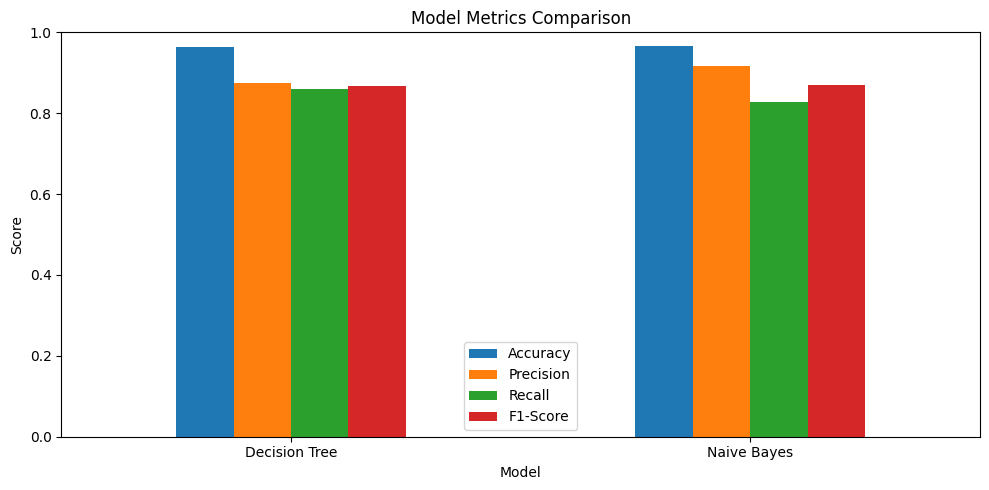

In [20]:
metrics_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_nb, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_nb, zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_nb, zero_division=0)
    ]
})

print(metrics_df)

plot_df = metrics_df.set_index('Model')
plot_df.plot(kind='bar', figsize=(10, 5))
plt.ylabel('Score')
plt.title('Model Metrics Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_cv = cross_val_score(
    DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced'),
    X, y, cv=cv, scoring='f1'
)

nb_cv = cross_val_score(
    BernoulliNB(),
    X, y, cv=cv, scoring='f1'
)

print('Decision Tree CV F1:', dt_cv)
print('Decision Tree Avg F1:', dt_cv.mean())

print('\nNaive Bayes CV F1:', nb_cv)
print('Naive Bayes Avg F1:', nb_cv.mean())

Decision Tree CV F1: [0.87837838 0.84768212 0.87213115 0.8125     0.85808581]
Decision Tree Avg F1: 0.8537554907411037

Naive Bayes CV F1: [0.8975265  0.85416667 0.86619718 0.85714286 0.88811189]
Naive Bayes Avg F1: 0.8726290193573576


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> The decision tree classified 161 of the spam messages as spam (true positive). The decision tree failed to classify 26 of the spam messages (false negative). The decision tree misclassified 23 ham messages (false positive).

*Naive Bayes:*
> The naive Bayes classifier correctly classified 155 of the spam messages as spam (true positive). The naive Bayes classifier failed to classify 32 of the spam messages (false negative). The naive Bayes classifier misclassified 14 ham messages (false positive).

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> Based on my selected metric (Precision), Naive Bayes is performing best. Naive Bayes is scoring .9172 for precision, while Decision Trees is scoring .8750. Therefore, Naive Bayes is outperforming Decision Trees by approximately .042. Also, based on the results from the cross-validation performed during step 6C, Naive Bayes was also shown to be outperforming Decision Trees (.8726 avg. F1-score for Naive Bayes and .8538 avg. F1-score for Decision Trees over all five-folds).

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
> I am recommending Naive Bayes for the mobile carrier's spam filter. Based upon the metrics provided for each model, Naive Bayes performed significantly better than Decision Trees on the metric that provides the greatest value for this problem. Specifically, Naive Bayes had a high precision rate of .9172, while Decision Trees had a low precision rate of .8750. Therefore, since Naive Bayes provides a much greater number of correct classifications regarding the presence or absence of spam messages, it is recommended that Naive Bayes be used as opposed to Decision Trees. One drawback to utilizing Naive Bayes is its ability to produce incorrect classification of some spam messages. In other words, there exists an opportunity for some spam messages to successfully evade the Naive Bayes model and be received by end-users. A potential method to increase the effectiveness of the Naive Bayes model would be to incorporate additional text features into the model. Examples of potentially useful features include but are not limited to; detecting phishing language within email messages, detecting URLs that contain malicious activity, and determining the relative frequency of certain words within email messages.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> There are two features I developed that would likely fail to effectively identify current forms of spam. These features include: "has_money" and "has_text_cmd". With regards to "has_money", this feature may fail to accurately identify many modern types of spam because they typically do not include obvious keywords related to money ("free", "win," etc.) in an effort to appear legitimate and avoid being blocked by spam filtering software. Additionally, the "has_text_cmd" feature may also fail because many modern spam messages utilize professional language and embedded links rather than instructing users to reply/text.
